In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import pandas as pd
import matplotlib.colors as mcolor


import warnings
warnings.filterwarnings("ignore")


ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [18]:
def fire_season(month):
    return (month >= 5) & (month <= 10)    
    
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

box = [(32,55),(232,256)]

In [19]:
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

ERA5 = ERA5.reindex(latitude=list(reversed(ERA5.latitude)))
ERA5 = ERA5.where(era5_vege_mask>0)
d4pdf = d4pdf.where(d4pdf_vege_mask>0)
cam5 = cam5.where(cam5_vege_mask>0)

ERA5 = ERA5.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
d4pdf = d4pdf.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
cam5 = cam5.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1])).sel(time=slice('1959','2014'))



In [20]:
# weighted areas

# ERA5
weights = np.cos(np.deg2rad(ERA5.latitude))
weights.name = "weights"
weighted_ERA5 = ERA5.weighted(weights)

# d4PDF-G
weights = np.cos(np.deg2rad(d4pdf.latitude))
weights.name = "weights"
weighted_d4pdf = d4pdf.weighted(weights)

# CAM5
weights = np.cos(np.deg2rad(cam5.latitude))
weights.name = "weights"
weighted_cam5 = cam5.weighted(weights)


In [21]:
'''
create 5th and 95th percentile datasets of regional time series across full ensembles
'''

# d4pdf
df_dict = {'year':d4pdf.time.dt.year.data.tolist()}
for ens_mem in range(1,101):
    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

    mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_m'+number+'.nc')
    mem_da = mem_da.where(d4pdf_vege_mask>0)
    mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    weights = np.cos(np.deg2rad(mem_da.latitude))
    weights.name = "weights"
    mem_da = mem_da.weighted(weights)

    ts = mem_da.mean(['latitude','longitude']).data.flatten()
    
    df_dict[number] = ts
    
d4pdf_df = pd.DataFrame.from_dict(df_dict)

fifth_list = []
ninetyfifth_list = []
for i in range(len(d4pdf_df)):
    a = d4pdf_df.loc[i]
    fifth_list.append(np.percentile(a,5))
    ninetyfifth_list.append(np.percentile(a,95))
    
d4pdf_df['5th'] = fifth_list
d4pdf_df['95th'] = ninetyfifth_list

# cam5
df_dict = {'year':cam5.time.dt.year.data.tolist()}
for ens_mem in [i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)]:
    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

    mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_run'+number+'.nc')
    mem_da = mem_da.where(cam5_vege_mask>0)
    mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1])).sel(time=slice('1959','2014'))
    weights = np.cos(np.deg2rad(mem_da.latitude))
    weights.name = "weights"
    mem_da = mem_da.weighted(weights)
    
    ts = mem_da.mean(['latitude','longitude']).data.flatten()
    
    df_dict[number] = ts
    
cam5_df = pd.DataFrame.from_dict(df_dict)

fifth_list = []
ninetyfifth_list = []
for i in range(len(cam5_df)):
    a = cam5_df.loc[i]
    fifth_list.append(np.percentile(a,5))
    ninetyfifth_list.append(np.percentile(a,95))
    
cam5_df['5th'] = fifth_list
cam5_df['95th'] = ninetyfifth_list


In [23]:
d4pdf_df

,year,001,002,003,004,005,006,007,008,009,...,093,094,095,096,097,098,099,100,5th,95th
0,1951,19.076036,19.923473,20.709239,16.476806,23.414187,21.766378,15.680533,19.995851,17.726974,...,19.666799,19.152634,16.609501,23.419928,21.469965,21.527415,19.977251,17.850108,16.665507,23.120999
1,1952,19.173762,21.109815,20.284917,16.565775,22.146351,18.668210,21.916331,22.974303,17.173475,...,25.840289,17.446492,20.747153,18.728752,19.732171,19.322929,18.709684,21.236659,17.446492,23.455792
2,1953,21.320501,19.508644,18.785844,18.594190,20.837939,20.341372,18.877973,20.729166,19.416352,...,20.954155,16.269612,21.064115,20.342799,16.521978,19.968778,18.648691,17.819913,16.639270,22.866572
3,1954,23.203128,23.856417,19.551954,19.539456,18.662929,22.340886,22.148636,20.385563,24.698097,...,18.922949,20.565318,18.571019,19.369311,18.810210,17.782807,19.535702,18.759206,17.481944,23.762160
4,1955,19.554108,21.075204,19.249893,19.961096,22.632733,20.612867,23.360643,20.406915,18.792337,...,16.776917,17.964733,18.631781,20.979424,19.060186,18.960670,20.873238,18.488583,17.650221,23.360643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,2017,18.601369,22.764267,20.596958,20.990277,21.752232,18.605103,17.681693,18.066591,20.662305,...,18.207328,18.225343,20.079856,21.013393,16.458752,17.356344,22.521734,22.404001,16.838970,23.058929
67,2018,20.698173,19.026016,17.914054,19.437761,21.673740,16.071323,20.553935,17.610848,16.918181,...,19.531600,17.338918,20.814888,22.316603,21.924508,18.998096,19.859652,19.143984,17.160804,23.143960
68,2019,20.927439,15.721341,20.328831,16.237663,17.736015,17.433573,19.872823,18.436046,19.815186,...,20.922978,18.851734,18.396895,18.824917,19.938106,21.237210,20.581145,17.674060,15.900496,21.674424
69,2020,19.326048,25.498540,20.147241,21.051483,21.677465,21.207587,21.297485,20.197867,20.099913,...,17.142086,19.511637,18.785787,21.857991,21.054873,24.630060,17.767510,22.251925,17.767510,24.079109


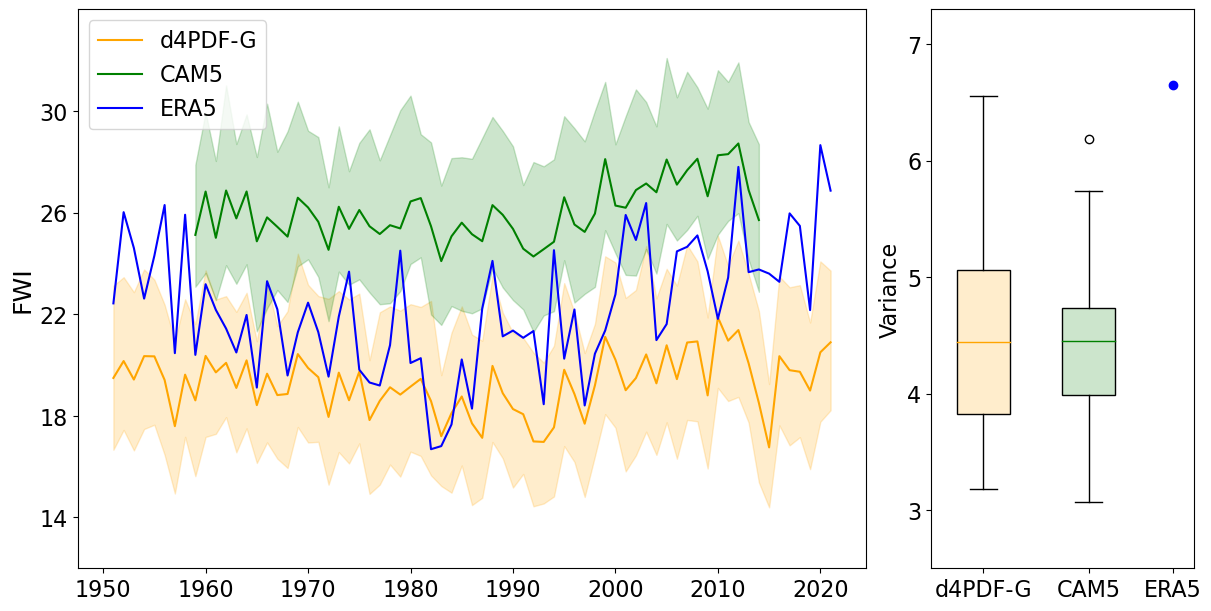

In [30]:
fig,axs = plt.subplots(1,2,figsize=(12,6),layout='constrained',gridspec_kw=dict(width_ratios=[3, 1]))

axs = axs.flatten()

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }

model_dict = {'d4PDF-G':[d4pdf,weighted_d4pdf,d4pdf_df,'orange'], 'CAM5':[cam5,weighted_cam5,cam5_df,'green'], 'ERA5':[ERA5,weighted_ERA5,[],'blue']}
for model in model_dict:
    mean_ts = model_dict[model][1].mean(['latitude','longitude'])
    x = model_dict[model][0].time.dt.year.data
    y = mean_ts.data.flatten()

    axs[0].plot(x,y,label=model, c = model_dict[model][3])
    
    if model in ['d4PDF-G','CAM5']:
        axs[0].fill_between(x, model_dict[model][2]['5th'], model_dict[model][2]['95th'], color=model_dict[model][3], alpha=0.2)
        

axs[0].legend(loc='upper left',fontsize=16)
axs[0].set_ylabel('FWI',fontdict=font)
font['size'] = 16
axs[0].set_xticks([1950+10*i for i in range(8)],labels=[str(1950+10*i) for i in range(8)],fontdict=font)
axs[0].set_yticks([14+4*i for i in range(5)],labels=[14+4*i for i in range(5)],fontdict=font)
axs[0].set_ylim(12,34)

d4pdf_var = []
for ens_mem in range(1,101):
    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

    d4pdf_var.append(np.var(d4pdf_df[number]))
    
cam5_var = []
for ens_mem in [i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)]:
    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

    cam5_var.append(np.var(cam5_df[number]))
    
era5_ts = weighted_ERA5.mean(['latitude','longitude'])

bplots = axs[1].boxplot([d4pdf_var,cam5_var],labels=['d4pdf','cam5'],patch_artist=True,widths=[0.5,0.5])
axs[1].scatter(2.8,np.var(era5_ts),color='blue')


# fill with colors
orange = (mcolor.to_rgba('orange')[0],mcolor.to_rgba('orange')[1],mcolor.to_rgba('orange')[2],0.2)
green = (mcolor.to_rgba('green')[0],mcolor.to_rgba('green')[1],mcolor.to_rgba('green')[2],0.2)
colors = [orange,green]
for patch, color in zip(bplots['boxes'], colors):
    patch.set_facecolor(color)
    
for median, color in zip(bplots['medians'], [mcolor.to_rgba('orange'),mcolor.to_rgba('green')]):
    median.set_color(color)
    
#font['size'] = 16
axs[1].set_xticks([1,2,2.8],labels=['d4PDF-G','CAM5','ERA5'],fontdict=font)
axs[1].set_yticks([3,4,5,6,7],labels=['3','4','5','6','7'],fontdict=font)   
axs[1].set_ylim(2.5,7.3)
axs[1].set_xlim(0.5,3)
axs[1].set_ylabel('Variance',fontdict=font)

plt.savefig('/home/queenle/fire_attribution/figures/Figure2.png',dpi=300)

(array([ 2.,  4.,  8., 11., 13., 11., 10.,  3.,  6.,  3.]),
 array([15.80690858, 16.91234239, 18.0177762 , 19.12321002, 20.22864383,
        21.33407764, 22.43951145, 23.54494527, 24.65037908, 25.75581289,
        26.8612467 ]),
 <BarContainer object of 10 artists>)

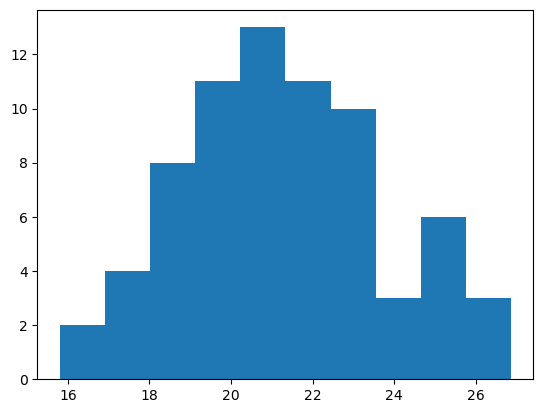

In [46]:
plt.hist(era5_ts)

(-1.0, 5.0)

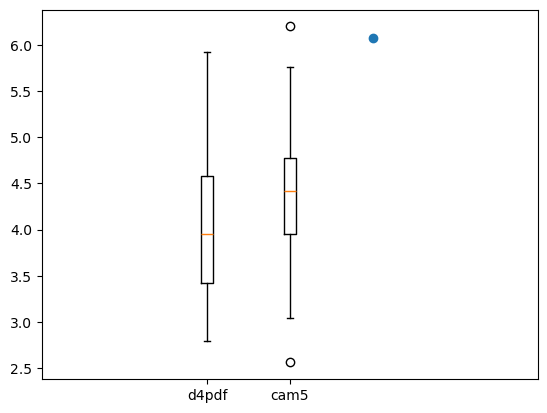

In [30]:
d4pdf_var = []
for ens_mem in range(1,101):
    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

    d4pdf_var.append(np.var(d4pdf_df[number]))
    
cam5_var = []
for ens_mem in [i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)]:
    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

    cam5_var.append(np.var(cam5_df[number]))
    
era5_ts = ERA5.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1])).mean(['latitude','longitude'])

plt.boxplot([d4pdf_var,cam5_var],labels=['d4pdf','cam5'])#,color='orange')
plt.scatter(3,np.var(era5_ts))
plt.xlim(-1,5)

(-7.9, 7.9)

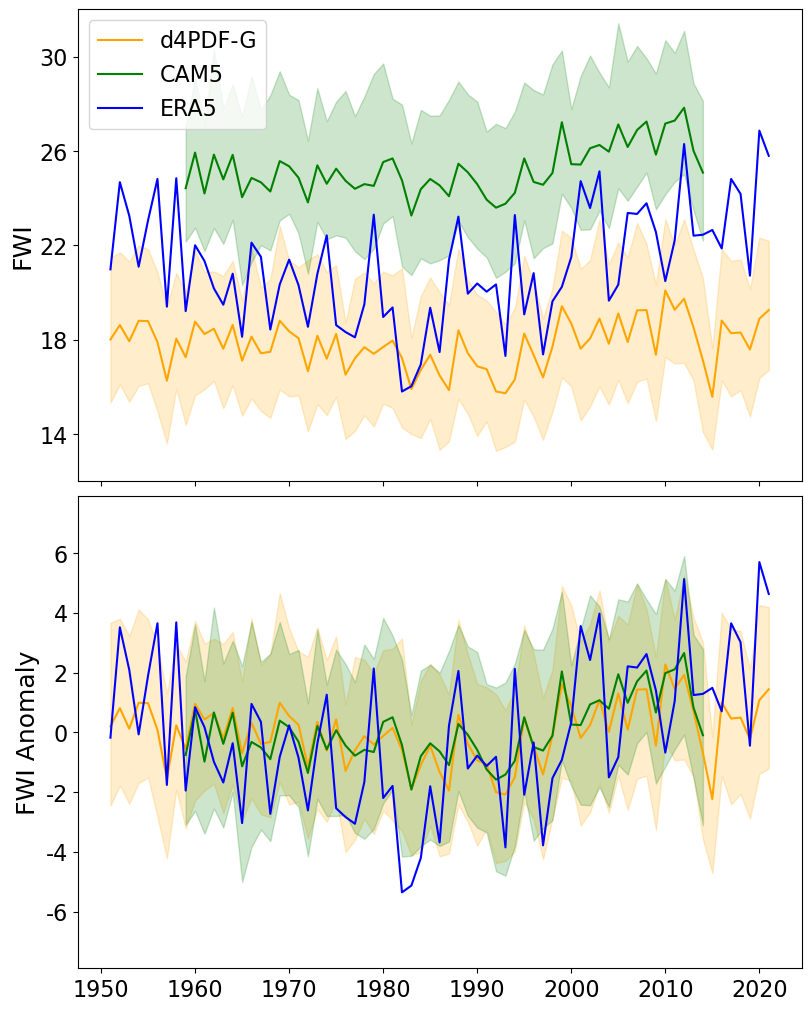

In [5]:
fig,axs = plt.subplots(2,1,figsize=(8,10),sharex=True,layout='constrained')
axs = axs.flatten()

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }

model_dict = {'d4PDF-G':[d4pdf,d4pdf_df,'orange'], 'CAM5':[cam5,cam5_df,'green'], 'ERA5':[ERA5,[],'blue']}
for model in model_dict:
    mean_ts = model_dict[model][0].sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1])).mean(['latitude','longitude'])
    x = mean_ts.time.dt.year.data
    y = mean_ts.data.flatten()

    axs[0].plot(x,y,label=model, c = model_dict[model][2])
    
    if model in ['d4PDF-G','CAM5']:
        axs[0].fill_between(x, model_dict[model][1]['5th'], model_dict[model][1]['95th'], color=model_dict[model][2], alpha=0.2)
        

axs[0].legend(loc='upper left',fontsize=16)
axs[0].set_ylabel('FWI',fontdict=font)
font['size'] = 16
axs[0].set_xticks([1950+10*i for i in range(8)],labels=[str(1950+10*i) for i in range(8)],fontdict=font)
axs[0].set_yticks([14+4*i for i in range(5)],labels=[14+4*i for i in range(5)],fontdict=font)
axs[0].set_ylim(12,32)

font['size'] = 18
model_dict = {'d4PDF-G':[d4pdf_anom,d4pdf_anom_df,'orange'], 'CAM5':[cam5_anom,cam5_anom_df,'green'], 'ERA5':[ERA5_anom,[],'blue']}
for model in model_dict:
    mean_ts = model_dict[model][0].sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1])).mean(['latitude','longitude'])
    x = mean_ts.time.dt.year.data
    y = mean_ts.data.flatten()

    axs[1].plot(x,y,c=model_dict[model][2])
    
    if model in ['d4PDF-G','CAM5']:
        axs[1].fill_between(x, model_dict[model][1]['5th'], model_dict[model][1]['95th'], color=model_dict[model][2], alpha=0.2)
        

axs[1].set_ylabel('FWI Anomaly',fontdict=font)
font['size'] = 16
axs[1].set_xticks([1950+10*i for i in range(8)],labels=[1950+10*i for i in range(8)],fontdict=font)
axs[1].set_yticks([-6+2*i for i in range(7)],labels=[-6+2*i for i in range(7)],fontdict=font)
axs[1].set_ylim(-7.9,7.9)

#plt.savefig('../figures/Figure2.png',dpi=300)


In [27]:
cam5_df.loc['1959':'2014']

,001,002,003,004,005,006,007,008,009,010,...,093,094,095,096,097,098,099,100,5th,95th
year,,,,,,,,,,,,,,,,,,,,,
1959,23.546707,21.265777,26.908728,24.452712,25.861675,23.392777,27.061581,23.503386,23.730581,22.226501,...,25.098223,26.146149,25.767781,25.122574,25.335623,23.283156,26.232175,24.028191,22.160001,27.038653
1960,28.607072,30.295805,26.560851,24.704430,26.950048,24.871893,24.447408,23.908849,22.590648,25.461840,...,27.737656,26.867852,26.224992,26.669123,25.555373,25.791607,27.534696,27.850223,22.747794,29.101071
1961,25.854277,26.912403,23.158052,25.584915,26.790017,24.720731,23.796279,22.887130,24.548717,26.905543,...,26.270743,22.480826,25.045498,25.077472,21.755769,22.763580,25.378487,23.697895,21.755047,27.078480
1962,24.887813,25.326293,25.819957,28.207739,24.754238,26.296859,24.552229,28.489353,30.496813,29.626713,...,25.413029,25.077673,24.447558,25.298758,26.404001,23.435077,27.064595,27.043277,22.738690,30.285179
1963,26.281028,22.451776,23.420233,24.562087,24.531974,21.651040,24.349872,25.083580,25.263911,22.016289,...,24.890456,22.910220,26.017691,26.811345,22.318858,25.433486,24.759439,26.262455,22.061674,27.782732
1964,26.545184,24.765752,23.209650,28.264231,29.502649,25.607479,27.020389,25.755123,25.771498,26.445624,...,25.556177,26.147859,24.656997,27.903671,21.082404,26.310929,22.546831,28.911605,23.082106,28.814499
1965,22.457864,24.196776,23.667719,24.589828,23.435935,24.620992,25.860601,22.895211,22.934425,23.676729,...,22.170011,27.295181,27.488813,22.065490,23.557697,19.932492,25.854674,24.115613,20.313399,27.459768
1966,25.363594,23.311219,28.366218,23.501962,23.894730,28.214202,24.900093,24.956692,22.156957,24.926357,...,24.978767,21.160617,25.250596,22.737272,25.267322,22.982009,27.408590,20.239506,21.287796,29.163929
1967,23.140400,24.069298,25.252041,25.188147,22.189235,27.335179,28.675150,27.661318,26.705305,22.467445,...,23.987000,26.399733,26.008271,23.304625,23.800651,23.018327,25.009585,23.585858,22.009971,27.744081


In [10]:
cam5_anom_df

,year,001,002,003,004,005,006,007,008,009,...,093,094,095,096,097,098,099,100,5th,95th
0,-29.5,-1.630148,-3.920539,2.305328,-1.257940,0.528611,-1.879512,2.076976,-1.786346,-1.603943,...,-0.207482,1.077823,0.617392,0.301131,0.180042,-1.969889,1.126703,-1.234706,-3.800381,1.822185
1,-28.5,3.430217,5.109489,1.957450,-1.006222,1.616984,-0.400396,-0.537197,-1.380883,-2.743876,...,2.431951,1.799526,1.074604,1.847679,0.399792,0.538562,2.429223,2.587327,-2.960068,3.600892
2,-27.5,0.677421,1.726088,-1.445348,-0.125737,1.456953,-0.551558,-1.188327,-2.402602,-0.785807,...,0.965038,-2.587501,-0.104890,0.256029,-3.399812,-2.489465,0.273015,-1.565001,-3.572439,1.701108
3,-26.5,-0.289042,0.139977,1.216557,2.497087,-0.578826,1.024570,-0.432376,3.199621,5.162289,...,0.107325,0.009346,-0.702831,0.477314,1.248420,-1.817968,1.959122,1.780380,-2.719354,4.118560
4,-25.5,1.104172,-2.734540,-1.183168,-1.148565,-0.801090,-3.621249,-0.634734,-0.206152,-0.070614,...,-0.415249,-2.158107,0.867303,1.989902,-2.836723,0.180441,-0.346033,0.999558,-3.314216,2.285837
5,-24.5,1.368329,-0.420564,-1.393750,2.553579,4.169585,0.335190,2.035784,0.465391,0.436973,...,0.250472,1.079533,-0.493391,3.082228,-4.073177,1.057884,-2.558641,3.648708,-2.485998,3.051711
6,-23.5,-2.718992,-0.989539,-0.935681,-1.120824,-1.897129,-0.651297,0.875995,-2.394521,-2.400099,...,-3.135694,2.226855,2.338424,-2.755953,-1.597884,-5.320553,0.749202,-1.147284,-5.217433,2.205584
7,-22.5,0.186739,-1.875096,3.762818,-2.208690,-1.438334,2.941913,-0.084512,-0.333040,-3.177567,...,-0.326938,-3.907710,0.100207,-2.084171,0.111741,-2.271036,2.303118,-5.023391,-4.180472,3.660934
8,-21.5,-2.036456,-1.117018,0.648641,-0.522505,-3.143829,2.062890,3.690545,2.371586,1.370781,...,-1.318705,1.331406,0.857883,-1.516819,-1.354930,-2.234719,-0.095888,-1.677038,-3.515095,2.337794
9,-20.5,-2.152797,-1.507077,-1.235620,-3.707807,-2.735357,-0.803193,-0.077188,-0.858192,2.767267,...,0.723167,-1.618436,-4.612384,-3.069804,3.576810,-0.746386,1.220979,-1.689835,-3.885343,2.559630


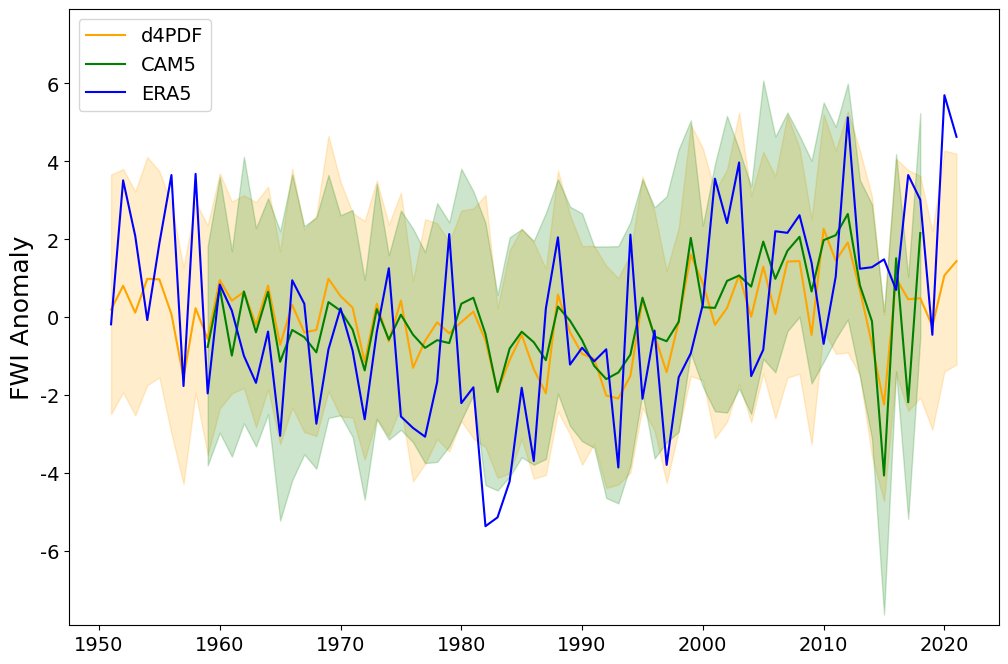

In [81]:
fig,axs = plt.subplots(figsize=(12,8))

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }

model_dict = {'d4PDF':[d4pdf_anom,d4pdf_anom_df,'orange'], 'CAM5':[cam5_anom,cam5_anom_df,'green'], 'ERA5':[ERA5_anom,[],'blue']}

for model in model_dict:
    mean_ts = model_dict[model][0].sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1])).mean(['latitude','longitude'])
    x = mean_ts.time.dt.year.data
    y = mean_ts.data.flatten()

    axs.plot(x,y,label=model, c = model_dict[model][2])
    
    if model in ['d4PDF','CAM5']:
        axs.fill_between(x, model_dict[model][1]['5th'], model_dict[model][1]['95th'], color=model_dict[model][2], alpha=0.2)
        

axs.legend(loc='upper left',fontsize=14)
axs.set_ylabel('FWI Anomaly',fontdict=font)
font['size'] = 14
axs.set_xticks([1950+10*i for i in range(8)],labels=[1950+10*i for i in range(8)],fontdict=font)
axs.set_yticks([-6+2*i for i in range(7)],labels=[-6+2*i for i in range(7)],fontdict=font)
axs.set_ylim(-7.9,7.9)

plt.savefig('../figures/Figure2_anom.png',dpi=300)

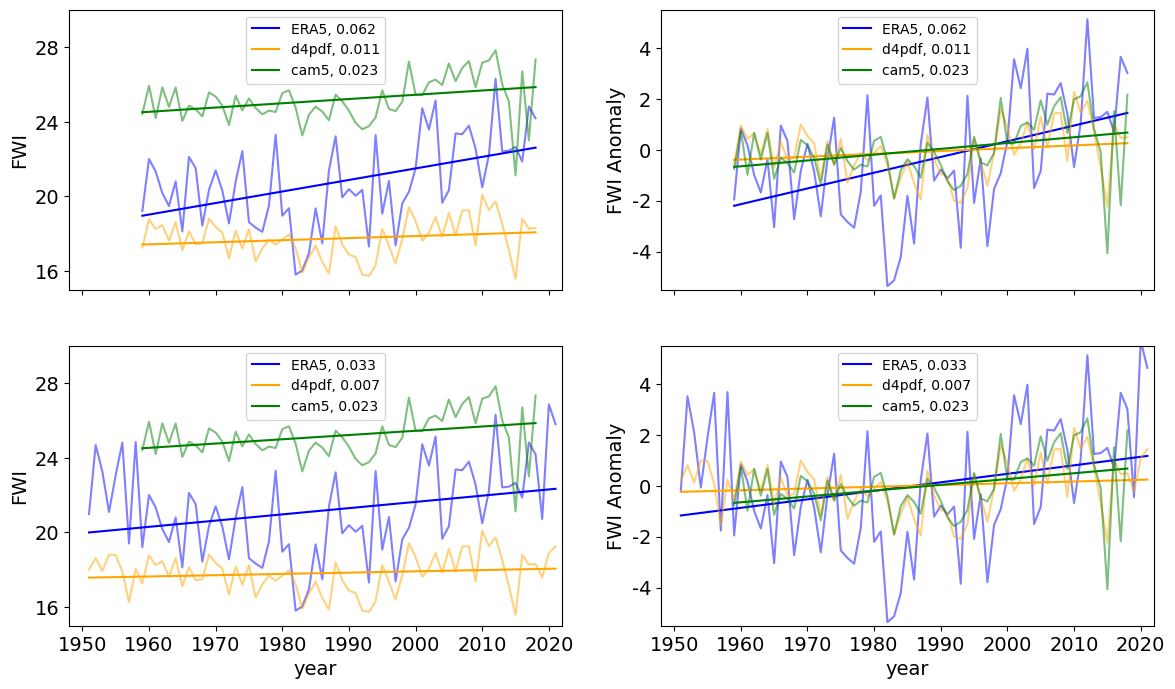

In [28]:
fig,axs = plt.subplots(2,2,figsize=(14,8),sharex=True)

box = [(32,55),(232,256)]

colors = ['blue','orange','green']
labels = ['ERA5','d4pdf','cam5']

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }

raw_das = [ERA5,d4pdf,cam5]
anom_das = [ERA5_anom,d4pdf_anom,cam5_anom]
for i,window in enumerate(['shared','full']):
    
    for j,da_list in enumerate([raw_das,anom_das]):
        
        for k,da in enumerate(da_list):
            if window == 'shared':
                da = da.sel(time=slice("1959","2018"))
            
            da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

            start_year = da.time.dt.year[0].data.tolist()

            ts = da.mean(['latitude','longitude']).data.flatten()
            axs[i][j].plot([i+start_year for i in range(len(ts))],ts,alpha=0.5,color=colors[k])
            m,b = np.polyfit([i for i in range(len(ts))],ts,deg=1)
            axs[i][j].plot([i+start_year for i in range(len(ts))],[m*i + b for i in range(len(ts))],color=colors[k],label=labels[k] + ', '+"{:.3f}".format(m))
            #axs[i][j].text(1997,16-0.5*i,str(m),color=colors[k])
            axs[i][j].legend(loc='upper center')
            axs[i][j].set_xlim(1948,2022)
            if j == 0:
                axs[i][j].set_ylim(15,30)
            elif j == 1:
                axs[i][j].set_ylim(-5.5,5.5)

font['size'] = 14
axs[0][0].set_ylabel('FWI', fontdict=font)
axs[0][0].set_yticks([16+4*i for i in range(4)],labels=[16+4*i for i in range(4)],fontdict=font)
axs[1][0].set_ylabel('FWI', fontdict=font)
axs[1][0].set_yticks([16+4*i for i in range(4)],labels=[16+4*i for i in range(4)],fontdict=font)

axs[0][1].set_ylabel('FWI Anomaly', fontdict=font)
axs[0][1].set_yticks([-4+2*i for i in range(5)],labels=[-4+2*i for i in range(5)],fontdict=font)
axs[1][1].set_ylabel('FWI Anomaly', fontdict=font)
axs[1][1].set_yticks([-4+2*i for i in range(5)],labels=[-4+2*i for i in range(5)],fontdict=font)

axs[1][0].set_xlabel('year', fontdict=font)
axs[1][0].set_xticks([1950+10*i for i in range(8)],labels=[1950+10*i for i in range(8)],fontdict=font)
axs[1][1].set_xlabel('year', fontdict=font)
axs[1][1].set_xticks([1950+10*i for i in range(8)],labels=[1950+10*i for i in range(8)],fontdict=font)


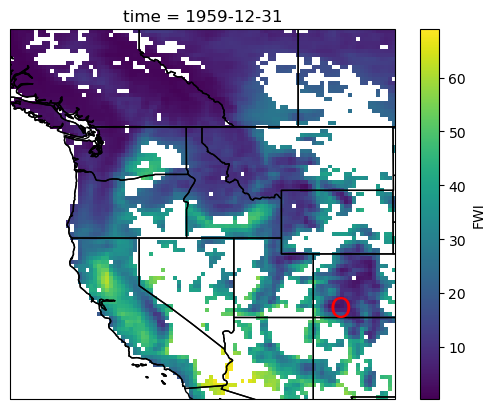

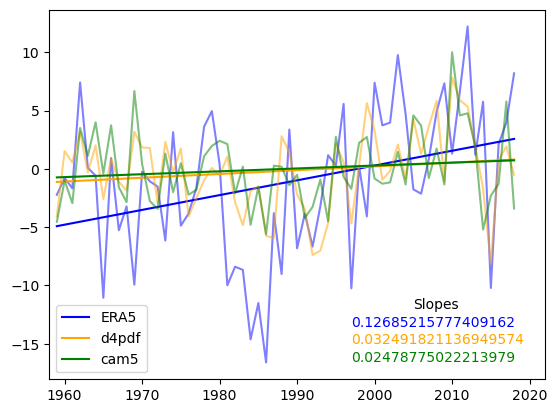

In [44]:
(lat,lon) = (37,252)

fig,axs = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
da = ERA5

da = da.sel(time=slice("1959","2018"))
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
axs.text(lon,lat,'O',c='red',fontsize=20,transform=ccrs.PlateCarree())

axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
        
plt.show()
plt.close()

plt.text(2005,-12,'Slopes')

ERA5_anom_ts = ERA5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,alpha=0.5,color='blue')
m,b = np.polyfit([i for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],[m*i + b for i in range(len(ERA5_anom_ts))],color='blue',label='ERA5')
plt.text(1997,-13.5,str(m),color='blue')

d4pdf_anom_ts = d4pdf_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,alpha=0.5,color='orange')
m,b = np.polyfit([i for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],[m*i + b for i in range(len(d4pdf_anom_ts))],color='orange',label='d4pdf')
plt.text(1997,-15,str(m),color='orange')

cam5_anom_ts = cam5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],cam5_anom_ts,alpha=0.5,color='green')
m,b = np.polyfit([i for i in range(len(cam5_anom_ts))],cam5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],[m*i + b for i in range(len(cam5_anom_ts))],color='green',label='cam5')
plt.text(1997,-16.5,str(m),color='green')

plt.xlim(1958,2022)
plt.legend()

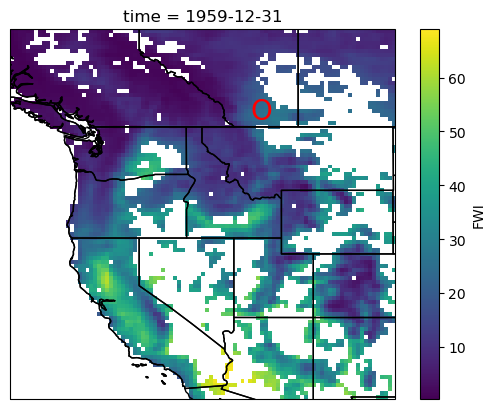

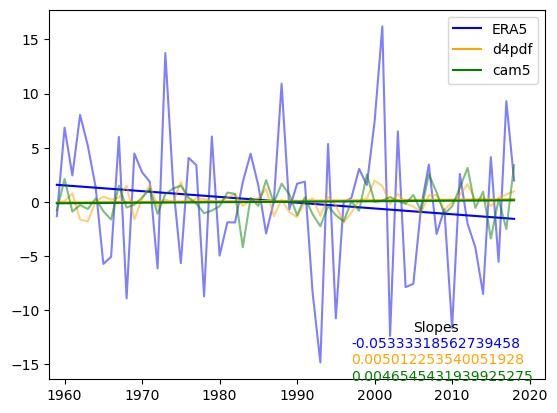

In [45]:
(lat,lon) = (49.5,247)

fig,axs = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
da = ERA5

da = da.sel(time=slice("1959","2018"))
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
axs.text(lon,lat,'O',c='red',fontsize=20,transform=ccrs.PlateCarree())

axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
        
plt.show()
plt.close()

plt.text(2005,-12,'Slopes')

ERA5_anom_ts = ERA5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,alpha=0.5,color='blue')
m,b = np.polyfit([i for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],[m*i + b for i in range(len(ERA5_anom_ts))],color='blue',label='ERA5')
plt.text(1997,-13.5,str(m),color='blue')

d4pdf_anom_ts = d4pdf_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,alpha=0.5,color='orange')
m,b = np.polyfit([i for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],[m*i + b for i in range(len(d4pdf_anom_ts))],color='orange',label='d4pdf')
plt.text(1997,-15,str(m),color='orange')

cam5_anom_ts = cam5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],cam5_anom_ts,alpha=0.5,color='green')
m,b = np.polyfit([i for i in range(len(cam5_anom_ts))],cam5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],[m*i + b for i in range(len(cam5_anom_ts))],color='green',label='cam5')
plt.text(1997,-16.5,str(m),color='green')

plt.xlim(1958,2022)
plt.legend()

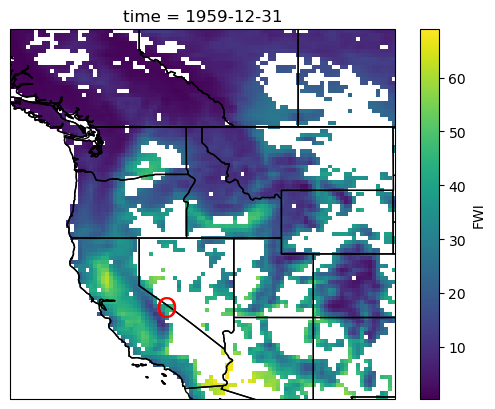

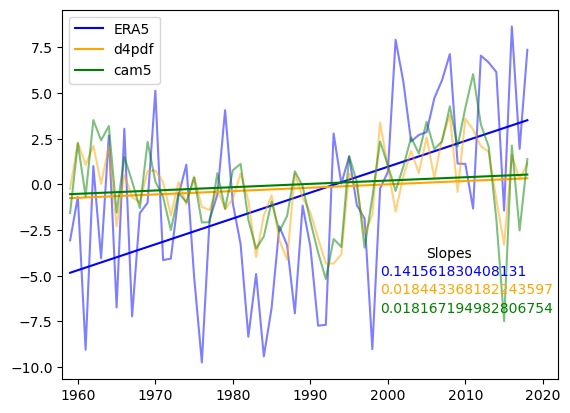

In [49]:
(lat,lon) = (37,241)

fig,axs = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
da = ERA5

da = da.sel(time=slice("1959","2018"))
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
axs.text(lon,lat,'O',c='red',fontsize=20,transform=ccrs.PlateCarree())

axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
        
plt.show()
plt.close()

plt.text(2005,-4,'Slopes')

ERA5_anom_ts = ERA5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,alpha=0.5,color='blue')
m,b = np.polyfit([i for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],[m*i + b for i in range(len(ERA5_anom_ts))],color='blue',label='ERA5')
plt.text(1999,-5,str(m),color='blue')

d4pdf_anom_ts = d4pdf_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,alpha=0.5,color='orange')
m,b = np.polyfit([i for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],[m*i + b for i in range(len(d4pdf_anom_ts))],color='orange',label='d4pdf')
plt.text(1999,-6,str(m),color='orange')

cam5_anom_ts = cam5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],cam5_anom_ts,alpha=0.5,color='green')
m,b = np.polyfit([i for i in range(len(cam5_anom_ts))],cam5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],[m*i + b for i in range(len(cam5_anom_ts))],color='green',label='cam5')
plt.text(1999,-7,str(m),color='green')

plt.xlim(1958,2022)
plt.legend()